In [1]:
from QLBM import QLBM, collision, InitializeQC
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 64, 16
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 15000
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [3]:
Q = 9
#U = 0.1
Nx = 63
Ny = 15#
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
f_star = np.zeros((Nx+1, Ny+1, Q))
fq = np.zeros((Nx+1, Ny+1, Q))
h_eq = np.zeros((Nx+1, Ny+1, Q))
h = np.zeros((Nx+1, Ny+1, Q))
h_star = np.zeros((Nx+1, Ny+1, Q))
hq = np.zeros((Nx+1, Ny+1, Q))
#tau_f = 1.0/(3*alpha + 0.5)
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
T = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])
#e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1]])
#w = np.array([2/6,1/6,1/6,1/6,1/6])
u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
T_n = T[:, :].copy() 
u_d = u[:, :, 0].copy()
v_d = u[:, :, 1].copy() 
T_d = T[:, :].copy() 
u_t = np.zeros((Nx+3, Ny+3))
v_t = np.zeros((Nx+3, Ny+3))
T_t = np.zeros((Nx+3, Ny+3))
uq_t = np.zeros((Nx+3, Ny+3))
vq_t = np.zeros((Nx+3, Ny+3))
Tq_t = np.zeros((Nx+3, Ny+3))
#X, Y = tanh_grid(Nx+1, Ny+1, x_range=(0, Nx), y_range=(0, Ny), k=1.0)
dx = dt = 1
c = dx/dt
Lx = Ny#1.6#
Ly = Ny

T_l = 1.0
T_r = 0.0
rho_beta = 4e-4#0.1**2/Lx#1e-7##np.sqrt(rho_beta*Lx*(T_l-T_r))#1e-7
T_star = (T_l+T_r)/2.0
Pr = 0.71
Ra = 100
Re = np.sqrt(Ra/Pr)
nu = np.sqrt((rho_beta*(T_l-T_r)*Pr*Lx**3)/Ra)
alpha = nu/Pr
y0 = np.linspace(0,2.0*np.pi,Nx+1,endpoint= False)
#x0 = np.linspace(-Lx+dx/2,Lx-dx/2,Nx+1)
print(y0)
x0 = np.linspace(Lx/1.6,Lx/1.6+Lx,Ny+1)
X0,Y0 = np.meshgrid(x0,y0)
X = X0*np.cos(Y0)
Y = X0*np.sin(Y0)
print(X.shape)
#X, Y = generate_nonuniform_grid(Nx+1, Ny+1, x_range=(0, Nx), y_range=(0, Ny), k=1.0)
#dx = dt = 1.0*np.min([np.min(np.sqrt((X[1:,:]-X[:-1,:])**2)),np.min(np.sqrt((X[:,1:]-X[:,:-1])**2)),np.min(np.sqrt((Y[1:,:]-Y[:-1,:])**2)),np.min(np.sqrt((Y[:,1:]-Y[:,:-1])**2))])
dx = dt = 0.9#/Ny*1.6#1.0*np.min([np.min(np.sqrt((X[:,1:]-X[:,:-1])**2)),np.min(np.sqrt((Y[1:,:]-Y[:-1,:])**2))])
X_t = np.zeros((Nx+3,Ny+3))
Y_t = np.zeros((Nx+3,Ny+3))
X_t1 = np.zeros((Nx+3,Ny+3))
Y_t1 = np.zeros((Nx+3,Ny+3))
X_t[1:-1,1:-1] = X0.copy()
X_t[0,:] = X_t[2,:]
X_t[-1,:] = X_t[-3,:]
X_t[:,0] = 2.0*X_t[:,1] - X_t[:,2]
X_t[:,-1] = 2.0*X_t[:,-2] - X_t[:,-3]
print(X_t.shape)
Y_t[1:-1,1:-1] = Y0.copy()#(X_t.T).copy()
Y_t[0,:] = 2.0*Y_t[1,:] - Y_t[2,:]
Y_t[-1,:] = 2.0*Y_t[-2,:] - Y_t[-3,:]
Y_t[:,0] = Y_t[:,1]
Y_t[:,-1] = Y_t[:,-2]
X_t1 = X_t*np.cos(Y_t)
Y_t1 = X_t*np.sin(Y_t)

print(np.max(X),np.min(X),np.min(Y[1:,:]-Y[:-1,:]),np.max(Y[1:,:]-Y[:-1,:]))
print(np.max(Y),np.min(Y),np.min(X[:,1:]-X[:,:-1]),np.max(X[:,1:]-X[:,:-1]))
delta_x = (X[:,1:]-X[:,:-1])#[:-1,:]
delta_y = (Y[1:,:]-Y[:-1,:])#[:,:-1]
deltat_x = (X_t[:,1:]-X_t[:,:-1])[1:-1,:]#[:-1,:]
deltat_y = (Y_t[1:,:]-Y_t[:-1,:])[:,1:-1]#[:,:-1]
print(delta_x.shape,delta_y.shape)
print(delta_x,delta_y)
y_0 = np.zeros((Nx+1,Ny+1,Q))
x_0 = np.zeros((Nx+1,Ny+1,Q))
for i in range(Q):
    x_0[:,:,i] = X + e[i,0]*dt
    y_0[:,:,i] = Y + e[i,1]*dt
#U = Re*nu/Lx
#nu = U * Lx / Re
#nu = U * Lx / Re
#alpha = 0.01
nu_star = 1/6*dt
alpha_star = 1/6*dt
cs = np.sqrt(c**2/3)
tau_f = 1.0#3.0*nu/dt+0.5#1.0#nu/(dt*cs**2) + 0.5
tau_h = 1.0#3.0*alpha/dt+0.5
t_s = 1.0
q_error = []
c_error = []
qc_error = []
#TIMESTEPS = int(t_s*Lx/U)
print(nu,nu_star,nu-nu_star,tau_f,cs**2)

[0.         0.09817477 0.19634954 0.29452431 0.39269908 0.49087385
 0.58904862 0.68722339 0.78539816 0.88357293 0.9817477  1.07992247
 1.17809725 1.27627202 1.37444679 1.47262156 1.57079633 1.6689711
 1.76714587 1.86532064 1.96349541 2.06167018 2.15984495 2.25801972
 2.35619449 2.45436926 2.55254403 2.6507188  2.74889357 2.84706834
 2.94524311 3.04341788 3.14159265 3.23976742 3.33794219 3.43611696
 3.53429174 3.63246651 3.73064128 3.82881605 3.92699082 4.02516559
 4.12334036 4.22151513 4.3196899  4.41786467 4.51603944 4.61421421
 4.71238898 4.81056375 4.90873852 5.00691329 5.10508806 5.20326283
 5.3014376  5.39961237 5.49778714 5.59596191 5.69413668 5.79231146
 5.89048623 5.988661   6.08683577 6.18501054]
(64, 16)
(66, 18)
24.375 -24.375 -2.3891677955330426 2.38916779553304
24.375 -24.375 -1.0 1.0
(64, 15) (63, 16)
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.0000

In [4]:
print(tau_f,tau_h,nu,alpha)

1.0 1.0 0.09790301323248432 0.13789156793307653


In [5]:
print(deltat_x,deltat_y,dt,dx,rho_beta,np.sqrt(rho_beta*Lx),nu-nu_star,alpha-alpha_star)

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] [[0.09817477 0.09817477 0.09817477 ... 0.09817477 0.09817477 0.09817477]
 [0.09817477 0.09817477 0.09817477 ... 0.09817477 0.09817477 0.09817477]
 [0.09817477 0.09817477 0.09817477 ... 0.09817477 0.09817477 0.09817477]
 ...
 [0.09817477 0.09817477 0.09817477 ... 0.09817477 0.09817477 0.09817477]
 [0.09817477 0.09817477 0.09817477 ... 0.09817477 0.09817477 0.09817477]
 [0.09817477 0.09817477 0.09817477 ... 0.09817477 0.09817477 0.09817477]] 0.9 0.9 0.0004 0.07745966692414834 -0.052096986767515674 -0.012108432066923469


In [6]:
print(x0,y0,dt,Lx)

[ 9.375 10.375 11.375 12.375 13.375 14.375 15.375 16.375 17.375 18.375
 19.375 20.375 21.375 22.375 23.375 24.375] [0.         0.09817477 0.19634954 0.29452431 0.39269908 0.49087385
 0.58904862 0.68722339 0.78539816 0.88357293 0.9817477  1.07992247
 1.17809725 1.27627202 1.37444679 1.47262156 1.57079633 1.6689711
 1.76714587 1.86532064 1.96349541 2.06167018 2.15984495 2.25801972
 2.35619449 2.45436926 2.55254403 2.6507188  2.74889357 2.84706834
 2.94524311 3.04341788 3.14159265 3.23976742 3.33794219 3.43611696
 3.53429174 3.63246651 3.73064128 3.82881605 3.92699082 4.02516559
 4.12334036 4.22151513 4.3196899  4.41786467 4.51603944 4.61421421
 4.71238898 4.81056375 4.90873852 5.00691329 5.10508806 5.20326283
 5.3014376  5.39961237 5.49778714 5.59596191 5.69413668 5.79231146
 5.89048623 5.988661   6.08683577 6.18501054] 0.9 15


In [7]:
print(x0.shape,x0,y0,dx)

(16,) [ 9.375 10.375 11.375 12.375 13.375 14.375 15.375 16.375 17.375 18.375
 19.375 20.375 21.375 22.375 23.375 24.375] [0.         0.09817477 0.19634954 0.29452431 0.39269908 0.49087385
 0.58904862 0.68722339 0.78539816 0.88357293 0.9817477  1.07992247
 1.17809725 1.27627202 1.37444679 1.47262156 1.57079633 1.6689711
 1.76714587 1.86532064 1.96349541 2.06167018 2.15984495 2.25801972
 2.35619449 2.45436926 2.55254403 2.6507188  2.74889357 2.84706834
 2.94524311 3.04341788 3.14159265 3.23976742 3.33794219 3.43611696
 3.53429174 3.63246651 3.73064128 3.82881605 3.92699082 4.02516559
 4.12334036 4.22151513 4.3196899  4.41786467 4.51603944 4.61421421
 4.71238898 4.81056375 4.90873852 5.00691329 5.10508806 5.20326283
 5.3014376  5.39961237 5.49778714 5.59596191 5.69413668 5.79231146
 5.89048623 5.988661   6.08683577 6.18501054] 0.9


In [8]:
print(x_0[:,:,5]-x_0[:,:,4],)

[[0.9 0.9 0.9 ... 0.9 0.9 0.9]
 [0.9 0.9 0.9 ... 0.9 0.9 0.9]
 [0.9 0.9 0.9 ... 0.9 0.9 0.9]
 ...
 [0.9 0.9 0.9 ... 0.9 0.9 0.9]
 [0.9 0.9 0.9 ... 0.9 0.9 0.9]
 [0.9 0.9 0.9 ... 0.9 0.9 0.9]]


In [9]:
print(dt)

0.9


In [10]:
QQ = 1
if QQ == 1:
    theta = 0.0
    dt1 = dt
elif QQ==2:
    theta = np.pi/2.0
    dt1 = dt
elif QQ==3:
    theta = np.pi
    dt1 = dt
elif QQ==4:
    theta = 3.0*np.pi/2.0
    dt1 = dt
elif QQ==5:
    theta = np.pi/4.0
    dt1 = dt*np.sqrt(2)
elif QQ==6:
    theta = 3.0*np.pi/4.0
    dt1 = dt*np.sqrt(2)
elif QQ==7:
    theta = 5.0*np.pi/4.0
    dt1 = dt*np.sqrt(2)
elif QQ==8:
    theta = 7.0*np.pi/4.0
    dt1 = dt*np.sqrt(2)
        
X_star1 = np.sqrt(X0**2 + dt1**2 + 2.0*X0*dt1*np.cos(Y0-theta))
Y_star1 = np.arctan2(X0*np.sin(Y0)+dt1*np.sin(theta),X0*np.cos(Y0)+dt1*np.cos(theta))
Y_star1 = np.where(Y_star1<0,Y_star1+2.0*np.pi,Y_star1)

In [11]:
print(np.min(X0),np.max(X0))
print(np.min(Y_star1[-1,:]),np.max(Y_star1[-1,:]),30*2.0*np.pi/32,2.0*np.pi)
print(np.min(Y0),np.max(Y0))

9.375 24.375
6.188501345706517 6.193599391161567 5.890486225480862 6.283185307179586
0.0 6.1850105367549055


In [12]:
print(np.max(X),np.min(X),np.min(np.abs(Y[1:,:]-Y[:-1,:])),np.max(Y[1:,:]-Y[:-1,:]))
print(np.max(Y),np.min(Y),np.min(np.abs(X[:,1:]-X[:,:-1])),np.max(X[:,1:]-X[:,:-1]))

24.375 -24.375 0.045143187448154265 2.38916779553304
24.375 -24.375 6.123233995736757e-17 1.0


In [13]:
print(2.0*np.pi)

6.283185307179586


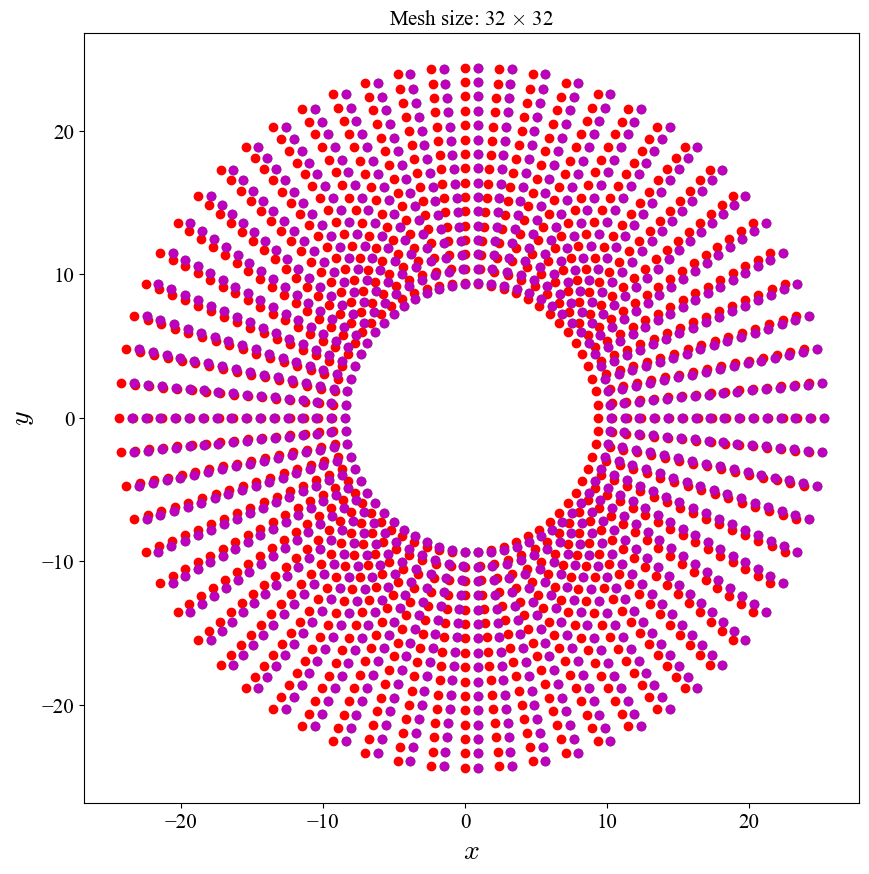

In [14]:
# 生成网格并可视化
plt.figure(figsize=(10, 10))
plt.scatter(X, Y, c='r')
plt.scatter(X_star1*np.cos(Y_star1),X_star1*np.sin(Y_star1), c='g')
plt.scatter(x_0[:,:,QQ], y_0[:,:,QQ], c='m')
#plt.scatter(X[-1,:], Y[-1,:], c='k')
#plt.scatter(X[1,:], Y[1,:], c='b')

#plt.scatter(X[:,-1], Y[:,-1], c='k')
#plt.scatter(X[:,1], Y[:,1], c='b')
#plt.xlim(-100,100)
#plt.ylim(400,450)
#plt.plot(X, Y, 'k', lw=0.5)
#plt.plot(X.T, Y.T, 'k', lw=0.5)
#plt.plot(X_t, Y_t, 'r--', lw=0.5)
#plt.plot(X_t.T, Y_t.T, 'r--', lw=0.5)
plt.xlabel('$x$',size = 20)#
plt.ylabel('$y$',size = 20)
plt.tick_params(labelsize=15)
#plt.plot(x_0[:,:,2], y_0[:,:,2], 'r', lw=0.5)
#plt.plot(x_0[:,:,2].T, y_0[:,:,2].T, 'r', lw=0.5)
plt.title('Mesh size: 32 $\\times$ 32',size = 15)

#plt.savefig(r'C:\Users\Dell\Desktop\Windows_NUS\Windows_NUAA\组会\2025\Report-20250704\Mesh_bfs.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

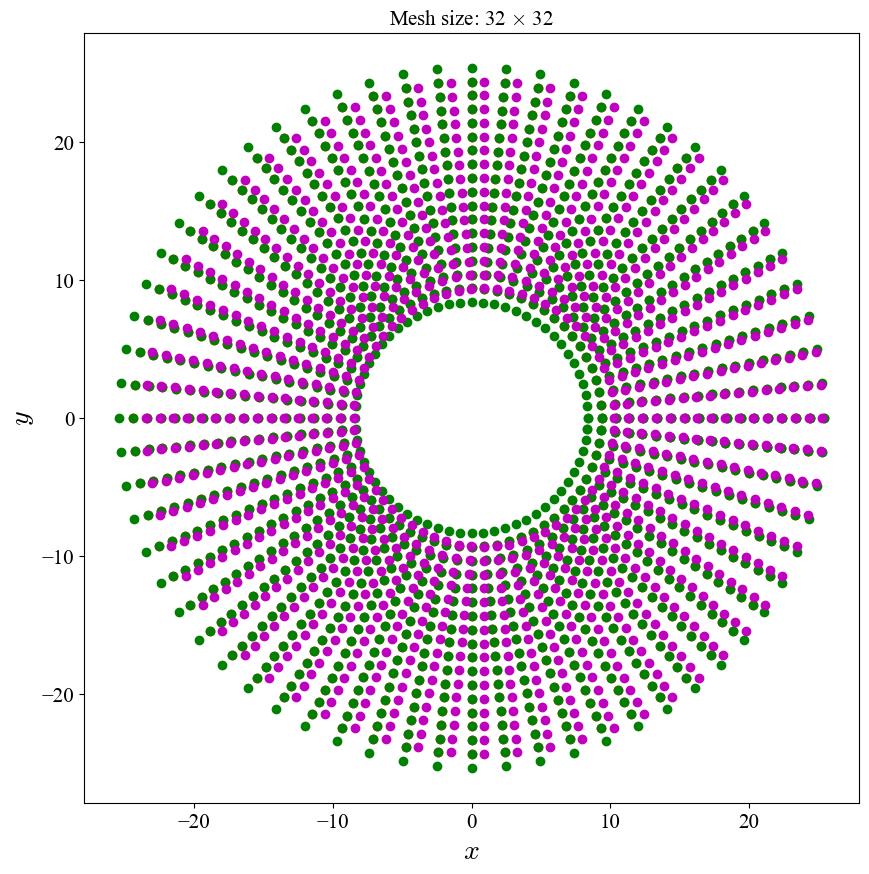

In [14]:
# 生成网格并可视化
plt.figure(figsize=(10, 10))
plt.scatter(X, Y, c='r')
plt.scatter(X_t1, Y_t1, c='g')
plt.scatter(x_0[:,:,1], y_0[:,:,1], c='m')
#plt.scatter(X[-1,:], Y[-1,:], c='k')
#plt.scatter(X[1,:], Y[1,:], c='b')

#plt.scatter(X[:,-1], Y[:,-1], c='k')
#plt.scatter(X[:,1], Y[:,1], c='b')
#plt.xlim(-100,100)
#plt.ylim(400,450)
#plt.plot(X, Y, 'k', lw=0.5)
#plt.plot(X.T, Y.T, 'k', lw=0.5)
#plt.plot(X_t, Y_t, 'r--', lw=0.5)
#plt.plot(X_t.T, Y_t.T, 'r--', lw=0.5)
plt.xlabel('$x$',size = 20)#
plt.ylabel('$y$',size = 20)
plt.tick_params(labelsize=15)
#plt.plot(x_0[:,:,2], y_0[:,:,2], 'r', lw=0.5)
#plt.plot(x_0[:,:,2].T, y_0[:,:,2].T, 'r', lw=0.5)
plt.title('Mesh size: 32 $\\times$ 32',size = 15)

#plt.savefig(r'C:\Users\Dell\Desktop\Windows_NUS\Windows_NUAA\组会\2025\Report-20250704\Mesh_bfs.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

In [15]:
print(np.max(X),np.min(X),np.min(Y[1:,:]-Y[:-1,:]),np.max(Y[1:,:]-Y[:-1,:]))
print(np.max(Y),np.min(Y),np.min(X[:,1:]-X[:,:-1]),np.max(X[:,1:]-X[:,:-1]))
print(np.max(x_0[:,:,1]),np.min(x_0[:,:,1]),np.min(y_0[:,:,1][1:,:]-y_0[:,:,1][:-1,:]),np.max(y_0[:,:,1][1:,:]-y_0[:,:,1][:-1,:]))
print(np.max(y_0[:,:,1]),np.min(y_0[:,:,1]),np.min(x_0[:,:,1][:,1:]-x_0[:,:,1][:,:-1]),np.max(x_0[:,:,1][:,1:]-x_0[:,:,1][:,:-1]))

24.375 -24.375 -2.3891677955330426 2.38916779553304
24.375 -24.375 -1.0 1.0
25.275 -23.475 -2.3891677955330426 2.38916779553304
24.375 -24.375 -1.0000000000000018 1.0


In [17]:
print(np.min(np.abs(X0)),np.max(X0))

9.375 24.375


In [16]:
neighbors = [list() for i in range(Nx-1)]
for ff in range(len(neighbors)):
    neighbors[ff].extend([list() for e in range(Ny-1)])
for i in range(1, Nx):
    for j in range(1, Ny):
        # 收集邻近点坐标 (包含9邻域)
        neighbors[i-1][j-1] = [
            (i,     j), (i-1, j), (i-1, j+1),
            (i-1, j-1), (i, j-1), (i,   j+1),
            (i+1, j-1), (i+1, j), (i+1, j+1)
        ]

neighbors0 = [list() for i in range(Ny-1)]
for j in range(1, Ny):
    # 收集邻近点坐标 (包含9邻域)
    neighbors0[j-1] = [
        (0,     j), (0-1, j), (0-1, j+1),
        (0-1, j-1), (0, j-1), (0,   j+1),
        (0+1, j-1), (0+1, j), (0+1, j+1)
    ]

neighbors1 = [list() for i in range(Ny-1)]
for j in range(1, Ny):
    # 收集邻近点坐标 (包含9邻域)
    neighbors1[j-1] = [
        (Nx,     j), (Nx-1, j), (Nx-1, j+1),
        (Nx-1, j-1), (Nx, j-1), (Nx,   j+1),
        (0, j-1), (0, j), (0, j+1)
    ]

In [17]:
## 3D
def Matrix_TL(X_star,Y_star, N_fx, N_fy,X_star1,Y_star1, n,neighbors,QQ):
    m = 6
    M1 = np.zeros((n,m))
    M2 = np.zeros((N_fx,N_fy-2,m,n))

    for i in range(N_fx):
        for j in range(1,N_fy-1):
            k = 0
            if i == 0:
                for (ni, nj) in neighbors0[j-1]:    
                    M1[k, 0] = 1.0
                    M1[k, 1] = (-X_star[i, j] + X_star1[ni, nj])
                    M1[k, 2] = (-Y_star[i, j] + Y_star1[ni, nj])
                    M1[k, 3] = 0.5*(-X_star[i, j] + X_star1[ni, nj])**2
                    M1[k, 4] = 0.5*(-Y_star[i, j] + Y_star1[ni, nj])**2
                    M1[k, 5] = (-X_star[i, j] + X_star1[ni, nj])*(-Y_star[i, j] + Y_star1[ni, nj])
                    k = k+1
            elif i == N_fx-1:
                for (ni, nj) in neighbors1[j-1]:
                    M1[k, 0] = 1.0
                    M1[k, 1] = (-X_star[i, j] + X_star1[ni, nj])
                    M1[k, 2] = (-Y_star[i, j] + Y_star1[ni, nj])
                    M1[k, 3] = 0.5*(-X_star[i, j] + X_star1[ni, nj])**2
                    M1[k, 4] = 0.5*(-Y_star[i, j] + Y_star1[ni, nj])**2
                    M1[k, 5] = (-X_star[i, j] + X_star1[ni, nj])*(-Y_star[i, j] + Y_star1[ni, nj])
                    k = k+1
            else:
                for (ni, nj) in neighbors[i-1][j-1]:
                    M1[k, 0] = 1.0
                    M1[k, 1] = (-X_star[i, j] + X_star1[ni, nj])
                    M1[k, 2] = (-Y_star[i, j] + Y_star1[ni, nj])
                    M1[k, 3] = 0.5*(-X_star[i, j] + X_star1[ni, nj])**2
                    M1[k, 4] = 0.5*(-Y_star[i, j] + Y_star1[ni, nj])**2
                    M1[k, 5] = (-X_star[i, j] + X_star1[ni, nj])*(-Y_star[i, j] + Y_star1[ni, nj])
                    k = k+1

            M2[i,j-1,:,:] = np.dot(np.linalg.inv(np.dot((M1.T), M1)), M1.T)
        
    return M2[:,:,0,:]

In [18]:
print(np.min(Y0[1:,:]-Y0[:-1,:])-2.0*np.pi/64,y0)

-3.3306690738754696e-16 [0.         0.09817477 0.19634954 0.29452431 0.39269908 0.49087385
 0.58904862 0.68722339 0.78539816 0.88357293 0.9817477  1.07992247
 1.17809725 1.27627202 1.37444679 1.47262156 1.57079633 1.6689711
 1.76714587 1.86532064 1.96349541 2.06167018 2.15984495 2.25801972
 2.35619449 2.45436926 2.55254403 2.6507188  2.74889357 2.84706834
 2.94524311 3.04341788 3.14159265 3.23976742 3.33794219 3.43611696
 3.53429174 3.63246651 3.73064128 3.82881605 3.92699082 4.02516559
 4.12334036 4.22151513 4.3196899  4.41786467 4.51603944 4.61421421
 4.71238898 4.81056375 4.90873852 5.00691329 5.10508806 5.20326283
 5.3014376  5.39961237 5.49778714 5.59596191 5.69413668 5.79231146
 5.89048623 5.988661   6.08683577 6.18501054]


In [19]:
## 3D
def Matrix_quadratic(X_star0,Y_star0, N_fx, N_fy,X_star1,Y_star1, n,neighbors,QQ):
    m = 6
    M = np.zeros((N_fx,N_fy-2,m,n))
    if QQ == 1:
        theta = np.pi
        dt1 = dt
    elif QQ==2:
        theta = 3.0*np.pi/2.0
        dt1 = dt
    elif QQ==3:
        theta = 0.0
        dt1 = dt
    elif QQ==4:
        theta = np.pi/2.0
        dt1 = dt
    elif QQ==5:
        theta = 5.0*np.pi/4.0
        dt1 = dt*np.sqrt(2)
    elif QQ==6:
        theta = 7.0*np.pi/4.0
        dt1 = dt*np.sqrt(2)
    elif QQ==7:
        theta = np.pi/4.0
        dt1 = dt*np.sqrt(2)
    elif QQ==8:
        theta = 3.0*np.pi/4.0
        dt1 = dt*np.sqrt(2)
        
    X_star = np.sqrt(X_star0**2 + dt1**2 + 2.0*X_star0*dt1*np.cos(Y_star0-theta))
    Y_star00 = np.arctan2(X_star0*np.sin(Y_star0)+dt1*np.sin(theta),X_star0*np.cos(Y_star0)+dt1*np.cos(theta))
    Y_star = np.where(Y_star00<0,Y_star00+2.0*np.pi,Y_star00)

    for i in range(N_fx):
        for j in range(1,N_fy-1):
            if i == 0:
                x0 = X_star1[neighbors0[j-1][4][0], neighbors0[j-1][4][1]]
                x1 = X_star1[neighbors0[j-1][0][0], neighbors0[j-1][0][1]]
                x2 = X_star1[neighbors0[j-1][2][0], neighbors0[j-1][2][1]]
                y0 = -2.0*np.pi/(Nx+1)#Y_star1[neighbors0[j-1][1][0], neighbors0[j-1][1][1]]
                y1 = 0.0#Y_star1[neighbors0[j-1][0][0], neighbors0[j-1][0][1]]
                y2 = 2.0*np.pi/(Nx+1)#Y_star1[neighbors0[j-1][6][0], neighbors0[j-1][6][1]]
                xm = X_star[i, j]
                if Y_star[i,j] > np.pi:
                    ym = Y_star[i, j] -2.0*np.pi
                else:
                    ym = Y_star[i, j]
                
            elif i == N_fx-1:
                x0 = X_star1[neighbors1[j-1][4][0], neighbors1[j-1][4][1]]
                x1 = X_star1[neighbors1[j-1][0][0], neighbors1[j-1][0][1]]
                x2 = X_star1[neighbors1[j-1][2][0], neighbors1[j-1][2][1]]
                y0 = (Nx-1)*2.0*np.pi/(Nx+1)#Y_star1[neighbors1[j-1][1][0], neighbors1[j-1][1][1]]
                y1 = (Nx)*2.0*np.pi/(Nx+1)#Y_star1[neighbors1[j-1][0][0], neighbors1[j-1][0][1]]
                y2 = (Nx+1)*2.0*np.pi/(Nx+1)#Y_star1[neighbors1[j-1][6][0], neighbors1[j-1][6][1]]
                xm = X_star[i, j]
                if Y_star[i,j]>np.pi:
                    ym = Y_star[i, j]
                else:
                    ym = Y_star[i, j] +2.0*np.pi
            else:
                x0 = X_star1[neighbors[i-1][j-1][4][0], neighbors[i-1][j-1][4][1]]
                x1 = X_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
                x2 = X_star1[neighbors[i-1][j-1][2][0], neighbors[i-1][j-1][2][1]]
                y0 = Y_star1[neighbors[i-1][j-1][1][0], neighbors[i-1][j-1][1][1]]
                y1 = Y_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
                y2 = Y_star1[neighbors[i-1][j-1][6][0], neighbors[i-1][j-1][6][1]]
                xm = X_star[i, j]
                ym = Y_star[i, j]
            M0 = (xm-x1)*(xm-x2)/((x0-x1)*(x0-x2))
            D0 = (ym-y1)*(ym-y2)/((y0-y1)*(y0-y2))
            M1 = (xm-x0)*(xm-x2)/((x1-x0)*(x1-x2))
            D1 = (ym-y0)*(ym-y2)/((y1-y0)*(y1-y2))
            M2 = (xm-x0)*(xm-x1)/((x2-x0)*(x2-x1))
            D2 = (ym-y0)*(ym-y1)/((y2-y0)*(y2-y1))
            M[i-1,j-1,0,0] = M1*D1
            M[i-1,j-1,0,1] = M1*D0
            M[i-1,j-1,0,2] = M2*D0
            M[i-1,j-1,0,3] = M0*D0
            M[i-1,j-1,0,4] = M0*D1
            M[i-1,j-1,0,5] = M2*D1
            M[i-1,j-1,0,6] = M0*D2
            M[i-1,j-1,0,7] = M1*D2
            M[i-1,j-1,0,8] = M2*D2

        
    return M[:,:,0,:]

In [20]:
MM = np.zeros((Nx+1,Ny-1,Q-1,9))
for ii in range(1,Q):
    #MM[:,:,ii-1,:] = Matrix_TL(X,Y, X.shape[0], X.shape[1],x_0[:,:,ii],y_0[:,:,ii],9,neighbors,ii)
    MM[:,:,ii-1,:] = Matrix_quadratic(X0,Y0, X.shape[0], X.shape[1],X0,Y0,9,neighbors,ii)

In [21]:
def matrix_SVD(M):
    Nxx, Nyy, _  = M.shape
    Nyy +=2
    M_SVD = np.zeros((Nxx*Nyy,Nxx*Nyy))
    for i in range(Nyy):
        for j in range(Nxx):
            MMS = np.zeros((Nxx,Nyy))
            if i == 0 or i == Nyy-1:
                MMS[j,i] = 1.0
            elif 0 < i < Nyy-1 and j == 0:
                MMS[0,i] = M[0,i-1,0]
                MMS[-1,i] = M[0,i-1,1]
                MMS[-1,i+1] = M[0,i-1,2]
                MMS[-1,i-1] = M[0,i-1,3]
                MMS[0,i-1] = M[0,i-1,4]
                MMS[0,i+1] = M[0,i-1,5]
                MMS[1,i-1] = M[0,i-1,6]
                MMS[1,i] = M[0,i-1,7]
                MMS[1,i+1] = M[0,i-1,8]
            elif 0 < i < Nyy-1 and j == Nxx-1:
                MMS[-1,i] = M[j,i-1,0]
                MMS[-2,i] = M[j,i-1,1]
                MMS[-2,i+1] = M[j,i-1,2]
                MMS[-2,i-1] = M[j,i-1,3]
                MMS[-1,i-1] = M[j,i-1,4]
                MMS[-1,i+1] = M[j,i-1,5]
                MMS[0,i-1] = M[j,i-1,6]
                MMS[0,i] = M[j,i-1,7]
                MMS[0,i+1] = M[j,i-1,8]
            else:
                MMS[j,i] = M[j,i-1,0]
                MMS[(j-1),i] = M[j,i-1,1]
                MMS[(j-1),i+1] = M[j,i-1,2]
                MMS[(j-1),i-1] = M[j,i-1,3]
                MMS[(j),i-1] = M[j,i-1,4]
                MMS[(j),i+1] = M[j,i-1,5]
                MMS[(j+1),i-1] = M[j,i-1,6]
                MMS[(j+1),i] = M[j,i-1,7]
                MMS[(j+1),i+1] = M[j,i-1,8]
            M_SVD[i*(Nxx)+j,:] = MMS.flatten(order='F')
    return M_SVD

In [22]:
M_s = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
M_SVD1 = np.zeros(((Nx+1)*(Ny+1),(Nx+1)*(Ny+1)))
for i in range(Ny+1):
    for j in range(Nx+1):
        MMS = np.zeros((Nx+1,Ny+1))
        MMS[j,i] = 1.0
        M_SVD1[i*(Nx+1)+j,:] = MMS.flatten(order='F')
M_s[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = M_SVD1

for i in range(1,Q):
    M_s[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = matrix_SVD(MM[:,:,i-1,:])

In [23]:
UU_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
S_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
VV_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
M_SVD1 = np.zeros(((Nx+1)*(Ny+1),(Nx+1)*(Ny+1)))
for i in range(Ny+1):
    for j in range(Nx+1):
        MMS = np.zeros((Nx+1,Ny+1))
        MMS[j,i] = 1.0
        M_SVD1[i*(Nx+1)+j,:] = MMS.flatten(order='F')
UU_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)],SSs,VV_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = np.linalg.svd(M_SVD1, full_matrices=False)
S_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = np.diag(SSs)

for i in range(1,Q):
    UUT2,SSs2,VVVT2 = np.linalg.svd(M_s[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)], full_matrices=False)

    UU_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] =UUT2
    S_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = np.diag(SSs2)
    VV_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = VVVT2

In [24]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator1 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [25]:
print(MM[0,0,5,:])
print(MM[5,5,5,:])

[ 0.05553919  0.23396144  0.66628765 -0.05377013 -0.01276428  0.15816742
  0.0030123  -0.01310695 -0.03732665]
[ 0.31015999  0.67047709  0.14237894 -0.07698578 -0.03561331  0.06586392
  0.0079804  -0.06950214 -0.0147591 ]


In [26]:
def possion_LSFD(f_hat,M):
    #print(dL.shape)

    vor_u1 = np.zeros_like(f_hat)


    vor_u1[1:-1,1:-1] = M[1:-1,:,0]*f_hat[1:-1,1:-1] + M[1:-1,:,1]*f_hat[0:-2,1:-1] + M[1:-1,:,2]*f_hat[0:-2,2:] + M[1:-1,:,3]*f_hat[0:-2,0:-2] + M[1:-1,:,4]*f_hat[1:-1,0:-2] + M[1:-1,:,5]*f_hat[1:-1,2:] +\
                        M[1:-1,:,6]*f_hat[2:,0:-2] + M[1:-1,:,7]*f_hat[2:,1:-1] + M[1:-1,:,8]*f_hat[2:,2:]
    
    vor_u1[0,1:-1] = M[0,:,0]*f_hat[0,1:-1] + M[0,:,1]*f_hat[-1,1:-1] + M[0,:,2]*f_hat[-1,2:] + M[0,:,3]*f_hat[-1,0:-2] + M[0,:,4]*f_hat[0,0:-2] + M[0,:,5]*f_hat[0,2:] +\
                        M[0,:,6]*f_hat[1,0:-2] + M[0,:,7]*f_hat[1,1:-1] + M[0,:,8]*f_hat[1,2:]
    vor_u1[-1,1:-1] = M[-1,:,0]*f_hat[-1,1:-1] + M[-1,:,1]*f_hat[-2,1:-1] + M[-1,:,2]*f_hat[-2,2:] + M[-1,:,3]*f_hat[-2,0:-2] + M[-1,:,4]*f_hat[-1,0:-2] + M[-1,:,5]*f_hat[-1,2:] +\
                        M[-1,:,6]*f_hat[0,0:-2] + M[-1,:,7]*f_hat[0,1:-1] + M[-1,:,8]*f_hat[0,2:]
        
    return vor_u1

In [27]:
print(deltat_x[0,0],deltat_y[0,0])

1.0 0.09817477042468103


In [28]:
# Initialize the quantum LBM scalar field
rho[:, :] = rho_0#-rho_0*U**2/(4*cs**2)*(np.cos(2.0*np.pi*X0/Lx)+np.sin(2.0*np.pi*Y0/Ly))
u[:, :, 0] = 0
u[:, :, 1] = 0
T[:, :] = T_star
T[:, 0] = T_r
T[:, -1] = T_l
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm3 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm3[0, :, :] = T.copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity
for t in range(1000000):
    #print(n)
    ##碰撞
    u_t[1:-1,1:-1] = u[:,:,0].copy()
    v_t[1:-1,1:-1] = u[:,:,1].copy()
    T_t[1:-1,1:-1] = T[:,:].copy()

    u_t[1:-1,0] = - u[:,1,0].copy()
    u_t[1:-1,-1] = -u[:,-2,0].copy()
    u_t[0,1:-1] = u[-1,:,0].copy()
    u_t[-1,1:-1] = u[0,:,0].copy()
    
    v_t[1:-1,0] = - u[:,1,1].copy()
    v_t[1:-1,-1] = -u[:,-2,1].copy()
    v_t[0,1:-1] = u[-1,:,1].copy()
    v_t[-1,1:-1] = u[0,:,1].copy()

    T_t[1:-1,0] = 2.0*T_r - T[:,1].copy()
    T_t[1:-1,-1] = 2.0*T_l -T[:,-2].copy()
    T_t[0,1:-1] = T[-1,:].copy()
    T_t[-1,1:-1] = T[0,:].copy()

    u_t_xy = 1/X0*(u_t[1:-1,2:] - u_t[1:-1,0:-2])/(2*deltat_x[0,0]) + (u_t[1:-1,2:] + u_t[1:-1,0:-2] - 2.0*u_t[1:-1,1:-1])/deltat_x[0,0]**2 + (u_t[2:,1:-1] + u_t[0:-2,1:-1] - 2.0*u_t[1:-1,1:-1])/deltat_y[0,0]**2/X0**2
    v_t_xy = 1/X0*(v_t[1:-1,2:] - v_t[1:-1,0:-2])/(2*deltat_x[0,0]) + (v_t[1:-1,2:] + v_t[1:-1,0:-2] - 2.0*v_t[1:-1,1:-1])/deltat_x[0,0]**2 + (v_t[2:,1:-1] + v_t[0:-2,1:-1] - 2.0*v_t[1:-1,1:-1])/deltat_y[0,0]**2/X0**2
    T_t_xy = 1/X0*(T_t[1:-1,2:] - T_t[1:-1,0:-2])/(2*deltat_x[0,0]) + (T_t[1:-1,2:] + T_t[1:-1,0:-2] - 2.0*T_t[1:-1,1:-1])/deltat_x[0,0]**2 + (T_t[2:,1:-1] + T_t[0:-2,1:-1] - 2.0*T_t[1:-1,1:-1])/deltat_y[0,0]**2/X0**2#""""""
    #u_d[:,1:-1], v_d[:,1:-1], T_d[:,1:-1]= possion_LSFD1(u[:,:,0],u[:,:,1],T,Lx2,Ly2,L1)

    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[0]*rho_beta*(T - T_star)*e[0,1]*dt
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[1]*rho_beta*(T - T_star)*e[1,1]*dt
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[2]*rho_beta*(T - T_star)*e[2,1]*dt
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[3]*rho_beta*(T - T_star)*e[3,1]*dt
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[4]*rho_beta*(T - T_star)*e[4,1]*dt
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[5]*rho_beta*(T - T_star)*e[5,1]*dt
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[6]*rho_beta*(T - T_star)*e[6,1]*dt
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[7]*rho_beta*(T - T_star)*e[7,1]*dt
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)#+ 3.0*w[8]*rho_beta*(T - T_star)*e[8,1]*dt
    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    h_eq[:, :, 0] = w[0] * (T)* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 1] = w[1] * (T)* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 2] = w[2] * (T)* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 3] = w[3] * (T)* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 4] = w[4] * (T)* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 5] = w[5] * (T)* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 6] = w[6] * (T)* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 7] = w[7] * (T)* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h_eq[:, :, 8] = w[8] * (T)* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    h[:, :, 0] = h[:, :, 0] - (h[:, :, 0] - h_eq[:, :, 0]) / tau_h
    h[:, :, 1] = h[:, :, 1] - (h[:, :, 1] - h_eq[:, :, 1]) / tau_h
    h[:, :, 2] = h[:, :, 2] - (h[:, :, 2] - h_eq[:, :, 2]) / tau_h
    h[:, :, 3] = h[:, :, 3] - (h[:, :, 3] - h_eq[:, :, 3]) / tau_h
    h[:, :, 4] = h[:, :, 4] - (h[:, :, 4] - h_eq[:, :, 4]) / tau_h
    h[:, :, 5] = h[:, :, 5] - (h[:, :, 5] - h_eq[:, :, 5]) / tau_h
    h[:, :, 6] = h[:, :, 6] - (h[:, :, 6] - h_eq[:, :, 6]) / tau_h
    h[:, :, 7] = h[:, :, 7] - (h[:, :, 7] - h_eq[:, :, 7]) / tau_h
    h[:, :, 8] = h[:, :, 8] - (h[:, :, 8] - h_eq[:, :, 8]) / tau_h

    ##迁移
    for i in range(1,Q):
        f[:, :,i] = possion_LSFD(f[:, :,i],MM[:,:,i-1,:])
        h[:, :,i] = possion_LSFD(h[:, :,i],MM[:,:,i-1,:])

    ##计算宏观量
    rho[:, :] = f[:, :, 0] + f[:, :, 1] +f[:, :, 2]+f[:, :, 3]+f[:, :, 4]+f[:, :, 5]+f[:, :, 6]+f[:, :, 7]+f[:, :, 8]
    u[:, :, 0] = (f[:, :, 1] - f[:, :, 3] + f[:, :, 5] - f[:, :, 6] - f[:, :, 7] + f[:, :, 8]) / rho[:, :]
    u[:, :, 1] = (f[:, :, 2] - f[:, :, 4] + f[:, :, 5] + f[:, :, 6] - f[:, :, 7] - f[:, :, 8]) / rho[:, :]#-rho_beta*(T - T_star)*dt
    rho[:, 0] = 2.0*rho[:,1] - rho[:,2]#rho[:,1]#4.0*rho[:,1]-6.0*rho[:,2] + 4.0*rho[:,3] - rho[:,4]#
    rho[:, Ny] = 2.0*rho[:,Ny-1] - rho[:,Ny-2]#rho[:,Ny-1]#4.0*rho[:,Ny-1] - 6.0*rho[:,Ny-2] + 4.0*rho[:,Ny-3] - rho[:,Ny-4]#
    u[:, 0, 0] = 0
    u[:, -1, 0] = 0
    u[:, 0, 1] = 0
    u[:, -1, 1] = 0
    u[:, :, 0] = u[:, :, 0] + dt*(nu-nu_star)*(u_t_xy)#
    u[:, :, 1] = u[:, :, 1] + dt*(nu-nu_star)*(v_t_xy)-rho_beta*(T - T_star)*dt
    u[:, 0, 0] = 0
    u[:, -1, 0] = 0
    u[:, 0, 1] = 0
    u[:, -1, 1] = 0

    T[:, :] = h[:, :, 0] + h[:, :, 1] +h[:, :, 2]+h[:, :, 3]+h[:, :, 4]+h[:, :, 5]+h[:, :, 6]+h[:, :, 7]+h[:, :, 8]
    T[:, 0] = T_r
    T[:, -1] = T_l
    T[:, :] = T[:, :] + dt*(alpha-alpha_star)*(T_t_xy)
    T[:, 0] = T_r
    T[:, -1] = T_l

    uq_t[1:-1,1:-1] = Psi_qlbm1[t, :, :].copy()
    vq_t[1:-1,1:-1] = Psi_qlbm2[t, :, :].copy()
    Tq_t[1:-1,1:-1] = Psi_qlbm3[t, :, :].copy()

    uq_t[1:-1,0] = - Psi_qlbm1[t,:,1].copy()
    uq_t[1:-1,-1] = -Psi_qlbm1[t,:,-2].copy()
    uq_t[0,1:-1] = Psi_qlbm1[t,-1,:].copy()
    uq_t[-1,1:-1] = Psi_qlbm1[t,0,:].copy()
    
    vq_t[1:-1,0] = - Psi_qlbm2[t,:,1].copy()
    vq_t[1:-1,-1] = -Psi_qlbm2[t,:,-2].copy()
    vq_t[0,1:-1] = Psi_qlbm2[t,-1,:].copy()
    vq_t[-1,1:-1] = Psi_qlbm2[t,0,:].copy()

    Tq_t[1:-1,0] = 2.0*T_r - Psi_qlbm3[t,:,1].copy()
    Tq_t[1:-1,-1] = 2.0*T_l -Psi_qlbm3[t,:,-2].copy()
    Tq_t[0,1:-1] = Psi_qlbm3[t,-1,:].copy()
    Tq_t[-1,1:-1] = Psi_qlbm3[t,0,:].copy()
    #print(X0.shape,uq_t[1:-1,1:-1].shape,deltat_x,delta_y)
    uq_t_xy = 1/X0*(uq_t[1:-1,2:] - uq_t[1:-1,0:-2])/(2*deltat_x[0,0]) + (uq_t[1:-1,2:] + uq_t[1:-1,0:-2] - 2.0*uq_t[1:-1,1:-1])/deltat_x[0,0]**2 + (uq_t[2:,1:-1] + uq_t[0:-2,1:-1] - 2.0*uq_t[1:-1,1:-1])/deltat_y[0,0]**2/X0**2
    vq_t_xy = 1/X0*(vq_t[1:-1,2:] - vq_t[1:-1,0:-2])/(2*deltat_x[0,0]) + (vq_t[1:-1,2:] + vq_t[1:-1,0:-2] - 2.0*vq_t[1:-1,1:-1])/deltat_x[0,0]**2 + (vq_t[2:,1:-1] + vq_t[0:-2,1:-1] - 2.0*vq_t[1:-1,1:-1])/deltat_y[0,0]**2/X0**2
    Tq_t_xy = 1/X0*(Tq_t[1:-1,2:] - Tq_t[1:-1,0:-2])/(2*deltat_x[0,0]) + (Tq_t[1:-1,2:] + Tq_t[1:-1,0:-2] - 2.0*Tq_t[1:-1,1:-1])/deltat_x[0,0]**2 + (Tq_t[2:,1:-1] + Tq_t[0:-2,1:-1] - 2.0*Tq_t[1:-1,1:-1])/deltat_y[0,0]**2/X0**2

    # Create and run the quantum circuit for LBM, rho
    zeros = np.zeros_like(Psi_qlbm[t, :, :])
    density_field1 = np.concatenate([Psi_qlbm[t, :, :]]*2,axis=None)
    T_field1 = np.concatenate([Psi_qlbm3[t, :, :]]*2,axis=None)
    for jj in range(9):
        U_SVDU = np.eye((Nx+1)*(Ny+1))
        S_SVDU = np.eye((Nx+1)*(Ny+1))
        V_SVDU = np.eye((Nx+1)*(Ny+1))
        U_SVDU[:(Nx+1)*(Ny+1),:(Nx+1)*(Ny+1)] = UU_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]
        S_SVDU[:(Nx+1)*(Ny+1),:(Nx+1)*(Ny+1)] = S_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]
        V_SVDU[:(Nx+1)*(Ny+1),:(Nx+1)*(Ny+1)] = VV_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]
        qc = QLBM(density_field=Psi_qlbm[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES,U_SVD = U_SVDU ,S_SVD = S_SVDU,V_SVD = V_SVDU,num = jj)
        compiled_circuit = transpile(qc, simulator)
        result = simulator.run(compiled_circuit).result()
    
        # Process the quantum statevector to update Psi_qlbm
        statevector = np.array(result.get_statevector())
        real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
        real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
        # Normalize and update the scalar field for the next timestep/np.sqrt(2)
        fq[:,:,jj] = real_part_statevector_reshaped * np.linalg.norm(density_field1.flatten())* np.linalg.norm(np.diag(S_SVDU).flatten())/np.sqrt(2.0)

        qc1 = QLBM(density_field=Psi_qlbm3[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES,U_SVD = U_SVDU ,S_SVD = S_SVDU,V_SVD = V_SVDU,num = jj)
        compiled_circuit1 = transpile(qc1, simulator1)
        result1 = simulator1.run(compiled_circuit1).result()
    
        # Process the quantum statevector to update Psi_qlbm
        statevector1 = np.array(result1.get_statevector())
        real_part_statevector1 = np.real(statevector1[:N_POINTS_X * N_POINTS_Y])
        real_part_statevector_reshaped1 = np.reshape(real_part_statevector1, (N_POINTS_X, N_POINTS_Y), order='F')
    
        # Normalize and update the scalar field for the next timestep/np.sqrt(2)
        hq[:,:,jj] = real_part_statevector_reshaped1 * np.linalg.norm(T_field1.flatten())* np.linalg.norm(np.diag(S_SVDU).flatten())/np.sqrt(2.0)

    Psi_qlbm[t + 1,:, :] = fq[:, :, 0] + fq[:, :, 1] +fq[:, :, 2]+fq[:, :, 3]+fq[:, :, 4]+fq[:, :, 5]+fq[:, :, 6]+fq[:, :, 7]+fq[:, :, 8]
    Psi_qlbm1[t + 1,:, :] = (fq[:, :, 1] - fq[:, :, 3] + fq[:, :, 5] - fq[:, :, 6] - fq[:, :, 7] + fq[:, :, 8]) / Psi_qlbm[t + 1,:, :]
    Psi_qlbm2[t + 1,:, :] = (fq[:, :, 2] - fq[:, :, 4] + fq[:, :, 5] + fq[:, :, 6] - fq[:, :, 7] - fq[:, :, 8]) / Psi_qlbm[t + 1,:, :]
    
    Psi_qlbm[t + 1,:, 0] = 2.0*Psi_qlbm[t + 1,:,1] - Psi_qlbm[t + 1,:,2]#rho[:,1]#4.0*rho[:,1]-6.0*rho[:,2] + 4.0*rho[:,3] - rho[:,4]#
    Psi_qlbm[t + 1,:, Ny] = 2.0*Psi_qlbm[t + 1,:,Ny-1] - Psi_qlbm[t + 1,:,Ny-2]#rho[:,Ny-1]#4.0*rho[:,Ny-1] - 6.0*rho[:,Ny-2] + 4.0*rho[:,Ny-3] - rho[:,Ny-4]#
    Psi_qlbm1[t + 1,:, 0] = 0
    Psi_qlbm1[t + 1,:, -1] = 0
    Psi_qlbm2[t + 1,:, 0] = 0
    Psi_qlbm2[t + 1,:, -1] = 0
    Psi_qlbm1[t + 1,:, :] = Psi_qlbm1[t + 1,:, :] + dt*(nu-nu_star)*(uq_t_xy)
    Psi_qlbm2[t + 1,:, :] = Psi_qlbm2[t + 1,:, :] + dt*(nu-nu_star)*(vq_t_xy)-rho_beta*(Psi_qlbm3[t,:, :] - T_star)*dt
    Psi_qlbm1[t + 1,:, 0] = 0
    Psi_qlbm1[t + 1,:, -1] = 0
    Psi_qlbm2[t + 1,:, 0] = 0
    Psi_qlbm2[t + 1,:, -1] = 0

    Psi_qlbm3[t + 1,:, :] = hq[:, :, 0] + hq[:, :, 1] +hq[:, :, 2]+hq[:, :, 3]+hq[:, :, 4]+hq[:, :, 5]+hq[:, :, 6]+hq[:, :, 7]+hq[:, :, 8]
    Psi_qlbm3[t + 1,:, 0] = T_r
    Psi_qlbm3[t + 1,:, -1] = T_l
    Psi_qlbm3[t + 1,:, :] = Psi_qlbm3[t + 1,:, :] + dt*(alpha-alpha_star)*(T_t_xy)
    Psi_qlbm3[t + 1,:, 0] = T_r
    Psi_qlbm3[t + 1,:, -1] = T_l

    

    """Psi_qlbm1[t + 1,:, 0] = U
    Psi_qlbm1[t + 1,0, :] = 0.0
    Psi_qlbm1[t + 1,Nx, :] = 0.0
    Psi_qlbm1[t + 1,:, Ny] = Psi_qlbm1[t + 1,:, Ny-1]
    #Psi_qlbm1[t + 1,:, 0] = Psi_qlbm1[t + 1,0, :] = Psi_qlbm1[t + 1,Ny, :] = 0.0
    #Psi_qlbm1[t + 1,:, Ny] = U

    Psi_qlbm2[t + 1,:, 0] = 0.0
    Psi_qlbm2[t + 1,0, :] = 0.0
    Psi_qlbm2[t + 1,Nx, :] = 0.0
    Psi_qlbm2[t + 1,:, Ny] = Psi_qlbm2[t + 1,:, Ny-1]"""
    
    #Psi_qlbm2[t + 1,:, 0] = Psi_qlbm2[t + 1,0, :] = Psi_qlbm2[t + 1,Ny, :] = Psi_qlbm2[t + 1,:, Ny] = 0.0 
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    #print(Psi_qlbm0)
    # error = np.sum(np.sqrt((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2))/np.sum(np.sqrt(u[:, :, 0]**2+u[:, :, 1]**2))
    
    error = np.sqrt(np.sum((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2+(T_n-T[:, :])**2))/np.sqrt(np.sum(u[:, :, 0]**2+u[:, :, 1]**2+T[:, :]**2))
    #print('Epoch:{}, error:{}'.format(t,error))
    T_n = T.copy()
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()
    """u_qlbm = u_n.copy()
    v_qlbm = v_n.copy()
    u_qlbm[1:-1,1:-1] = Psi_qlbm1[t + 1, 1:-1, 1:-1]
    Psi_qlbm1[t + 1, :, :] = u_qlbm
    v_qlbm[1:-1,1:-1] = Psi_qlbm2[t + 1, 1:-1, 1:-1]
    Psi_qlbm2[t + 1, :, :] = v_qlbm"""
    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sqrt(np.sum((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2+(Psi_qlbm3[t + 1, :, :]-Psi_qlbm3[t, :, :])**2))/np.sqrt(np.sum(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2+Psi_qlbm3[t + 1, :, :]**2))
    error2 = np.sqrt(np.sum((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2+(Psi_qlbm3[t + 1, :, :]-T_n)**2))/np.sqrt(np.sum(u_n**2+v_n**2+T_n**2))
    #if t % 1000 ==0:
        #np.savetxt("Re=200/QLBM_u_Re_200_21_48_"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
        #np.savetxt("Re=200/QLBM_v_Re_200_21_48_"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
        #np.savetxt("Re=200/QLBM_rho_Re_200_21_48_"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
        #np.savetxt("Re=200/CLBM_u_Re_200_21_48_"+str(t)+".csv",u[:,:,0],delimiter=",")
        #np.savetxt("Re=200/CLBM_v_Re_200_21_48_"+str(t)+".csv",u[:,:,1],delimiter=",")
        #np.savetxt("Re=200/CLBM_rho_Re_200_21_48_"+str(t)+".csv",rho,delimiter=",")
    
    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error1 < 1e-8:
        break
    print(t, error, error1, error2)

0 1.0 0.04076769752534295 4.514290952395001e-13
1 0.0309924731775721 0.03099247317756401 4.937621138826344e-13
2 0.02474038900429922 0.024740389041917284 1.4208814582798658e-10
3 0.020549979098208434 0.0205499791439118 1.4765178844924025e-09
4 0.017603073689482326 0.017603073864158502 2.1927441069217205e-09
5 0.015436426314809043 0.01543642637087324 2.7370858581607232e-09
6 0.013781044628461683 0.013781044661134358 3.2005466243711895e-09
7 0.012475168988773737 0.012475169057433712 3.9445112415823095e-09
8 0.011417607296756192 0.011417607393027678 4.683985246125378e-09
9 0.010542501344137152 0.01054250144756022 5.457296331409208e-09
10 0.009805374412534646 0.009805374439347793 5.921529375699649e-09
11 0.009175175526396106 0.009175175468448241 6.345398536289794e-09
12 0.00862958358504658 0.008629583573662312 6.6588495027069695e-09
13 0.008152136987750382 0.008152136910197977 6.98827218856688e-09
14 0.0077304197216612565 0.007730419623702544 7.200996437665926e-09
15 0.007354879665957363 0

In [29]:
print(t, error, error1, error2)

2135 9.959300063775033e-09 9.964734316751334e-09 3.3658923492396797e-09


In [ ]:
np.savetxt("Ra=100/QLBM_u_Ra_100_64_16_"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Ra=100/QLBM_v_Ra_100_64_16_"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Ra=100/QLBM_rho_Ra_100_64_16_"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Ra=100/QLBM_T_Ra_100_64_16_"+str(t)+".csv",Psi_qlbm3[t+1,:,:],delimiter=",")
np.savetxt("Ra=100/CLBM_u_Ra_100_64_16_"+str(t)+".csv",u[:,:,0],delimiter=",")
np.savetxt("Ra=100/CLBM_v_Ra_100_64_16_"+str(t)+".csv",u[:,:,1],delimiter=",")
np.savetxt("Ra=100/CLBM_rho_Ra_100_64_16_"+str(t)+".csv",rho,delimiter=",")
np.savetxt("Ra=100/CLBM_T_Ra_100_64_16_"+str(t)+".csv",T,delimiter=",")

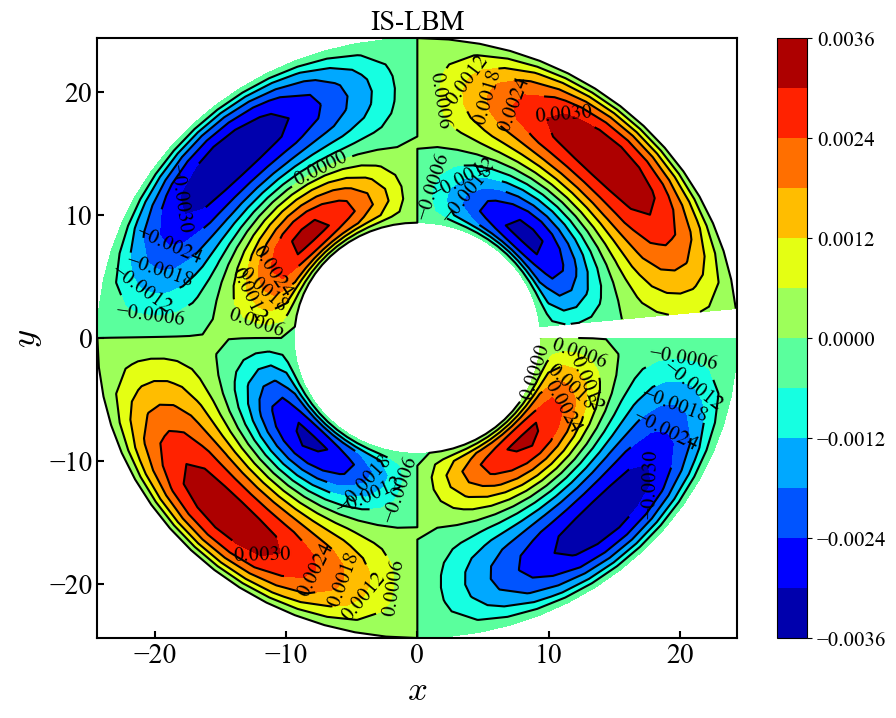

In [30]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
X1 = X0*np.cos(Y0+2.0*np.pi/(Nx+1))
Y1 = X0*np.sin(Y0+2.0*np.pi/(Nx+1))
fig = plt.figure(figsize=(10,10))
ax1 = plt.axes([0.056, 0.2, 0.8, 0.6])
ax01=plt.contourf(X1,Y1,u[:,:,0], 11,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X1,Y1,u[:,:,0],11,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('IS-LBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)
#plt.savefig('plot_u_classical.jpg', format='jpg',bbox_inches='tight', dpi=200)

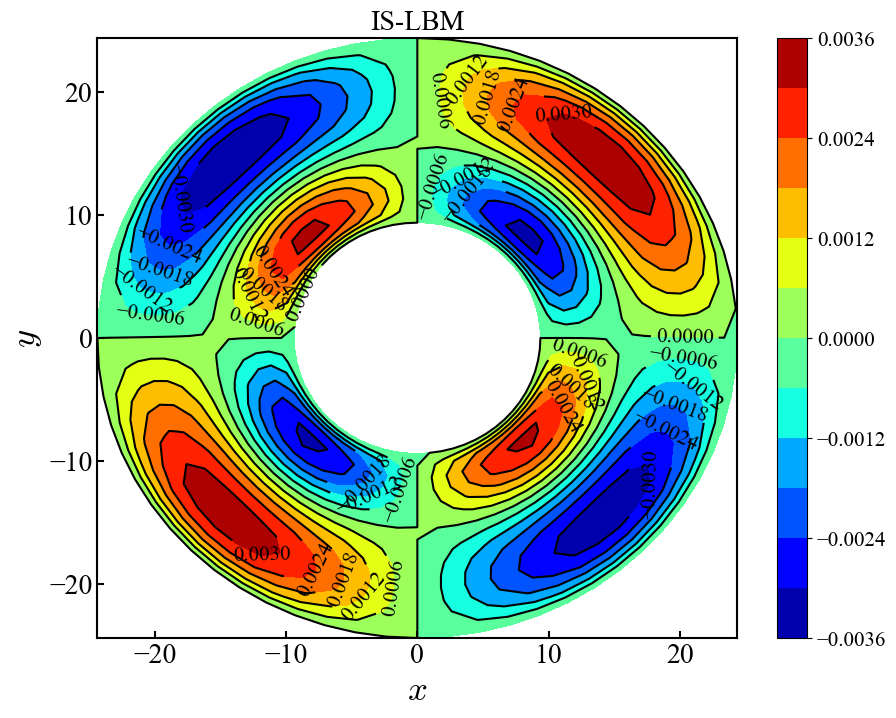

In [31]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
u00 = np.zeros((u[:,:,0].shape[0]+1,u[:,:,0].shape[1]))
u00[:-1,:] = u[:,:,0]
u00[-1,:] = u[0,:,0]
X00 = np.zeros((X1[:,:].shape[0]+1,X1[:,:].shape[1]))
X00[:-1,:] = X1[:,:]
X00[-1,:]  = X1[0,:]
Y00 = np.zeros((Y1[:,:].shape[0]+1,Y1[:,:].shape[1]))
Y00[:-1,:] = Y1[:,:]
Y00[-1,:]  = Y1[0,:]
fig = plt.figure(figsize=(10,10))
ax1 = plt.axes([0.056, 0.2, 0.8, 0.6])
ax01=plt.contourf(X00,Y00,u00, 11,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X00,Y00,u00,11,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('IS-LBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)
#plt.savefig('plot_u_classical_1.jpg', format='jpg',bbox_inches='tight', dpi=200)

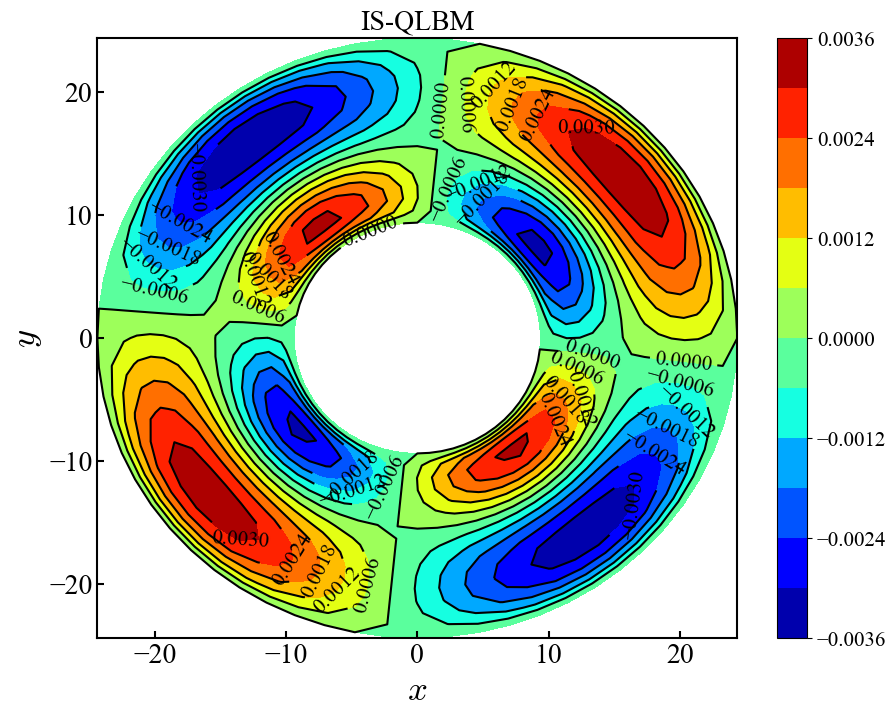

In [32]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
u_q0 = np.zeros((Psi_qlbm1[t+1,:,:].shape[0]+1,Psi_qlbm1[t+1,:,:].shape[1]))
u_q0[:-1,:] = Psi_qlbm1[t+1,:,:]
u_q0[-1,:] = Psi_qlbm1[t+1,0,:]
X00 = np.zeros((X[:,:].shape[0]+1,X[:,:].shape[1]))
X00[:-1,:] = X[:,:]
X00[-1,:]  = X[0,:]
Y00 = np.zeros((Y[:,:].shape[0]+1,Y[:,:].shape[1]))
Y00[:-1,:] = Y[:,:]
Y00[-1,:]  = Y[0,:]
fig = plt.figure(figsize=(10,10))
ax1 = plt.axes([0.056, 0.2, 0.8, 0.6])
ax01=plt.contourf(X00,Y00,u_q0, 11,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X00,Y00,u_q0,11,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('IS-QLBM', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)
#plt.savefig('plot_u_quantum.jpg', format='jpg',bbox_inches='tight', dpi=200)

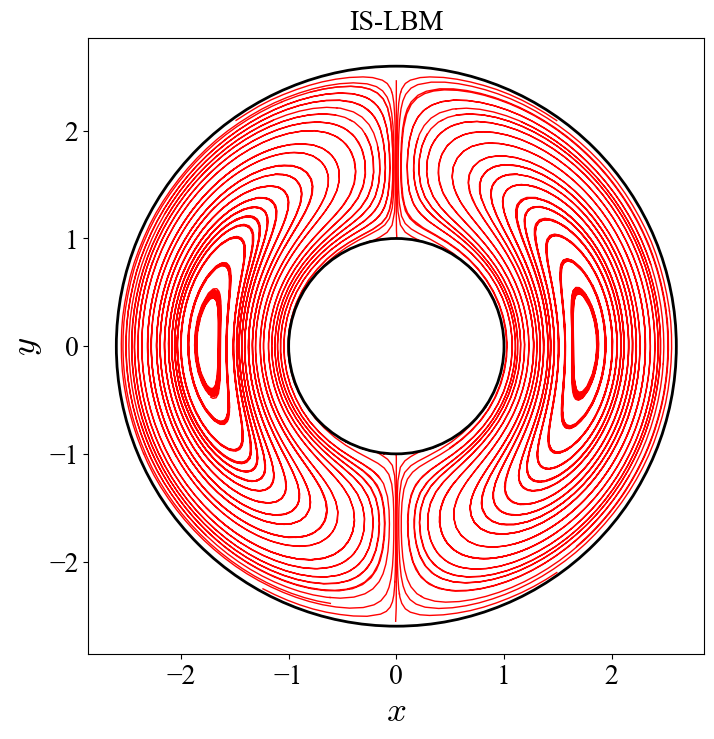

In [45]:
from scipy.interpolate import griddata

num_r = 300
num_theta = 300

x_min, x_max = -Lx/1.6*2.6 * 1.1, Lx/1.6*2.6 * 1.1
y_min, y_max = -Lx/1.6*2.6 * 1.1, Lx/1.6*2.6 * 1.1
x_vals = np.linspace(x_min, x_max, num_r)
y_vals = np.linspace(y_min, y_max, num_theta)
X_cart, Y_cart = np.meshgrid(x_vals, y_vals)

points = np.column_stack((X1.ravel(), Y1.ravel()))

Ux_interp = griddata(points, u[:,:,0].ravel(), (X_cart, Y_cart), method='cubic')
Uy_interp = griddata(points, u[:,:,1].ravel(), (X_cart, Y_cart), method='cubic')

circle_mask = (X_cart**2 + Y_cart**2) > (Lx/1.6*2.6)**2
Ux_interp[circle_mask] = np.nan
Uy_interp[circle_mask] = np.nan

plt.figure(figsize=(8, 8))
plt.streamplot(X_cart/(Lx/1.6), Y_cart/(Lx/1.6), Ux_interp, Uy_interp, density=1.5,arrowstyle='-', color='red', linewidth=1,broken_streamlines=False)


circle = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='white', fill=True, linestyle='-', linewidth=0.1,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle)
circle1 = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle1)
circle2 = plt.Circle((0, 0), Lx/1.6*2.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle2)

plt.xlim(x_min/(Lx/1.6), x_max/(Lx/1.6))
plt.ylim(y_min/(Lx/1.6), y_max/(Lx/1.6))
plt.gca().set_aspect('equal')
plt.xlabel('$x$', size = 25,fontdict = font1)
plt.ylabel('$y$', size = 25,fontdict = font1)    
plt.title('IS-LBM', fontsize = 20,fontdict = font)
plt.tick_params(labelsize=20)
#plt.savefig('Ra=100_streamline_classical.jpg', format='jpg',bbox_inches='tight', dpi=200)

plt.show()

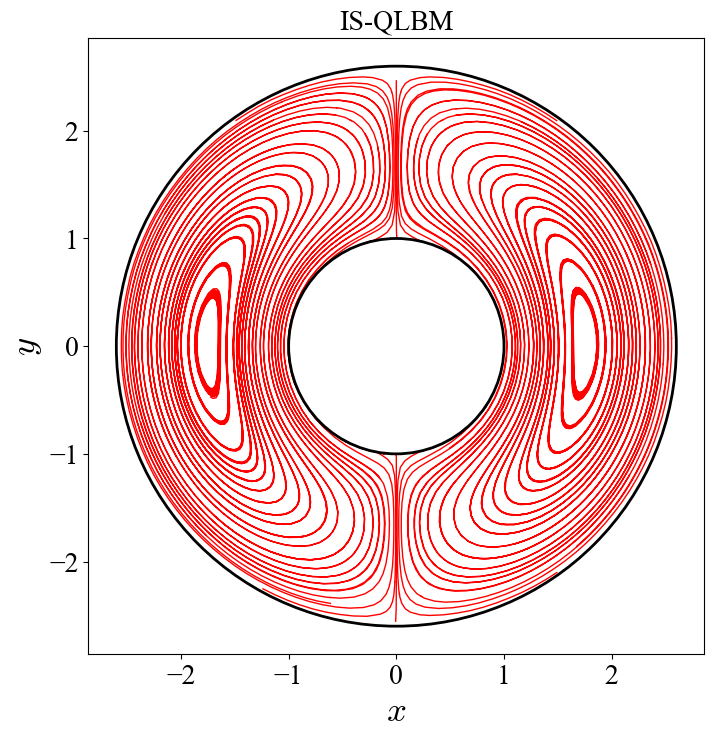

In [46]:
from scipy.interpolate import griddata

num_r = 300
num_theta = 300

x_min, x_max = -Lx/1.6*2.6 * 1.1, Lx/1.6*2.6 * 1.1
y_min, y_max = -Lx/1.6*2.6 * 1.1, Lx/1.6*2.6 * 1.1
x_vals = np.linspace(x_min, x_max, num_r)
y_vals = np.linspace(y_min, y_max, num_theta)
X_cart, Y_cart = np.meshgrid(x_vals, y_vals)

points = np.column_stack((X1.ravel(), Y1.ravel()))

Ux_interp_q = griddata(points, Psi_qlbm1[t+1,:,:].ravel(), (X_cart, Y_cart), method='cubic')
Uy_interp_q = griddata(points, Psi_qlbm2[t+1,:,:].ravel(), (X_cart, Y_cart), method='cubic')

circle_mask = (X_cart**2 + Y_cart**2) > (Lx/1.6*2.6)**2
Ux_interp_q[circle_mask] = np.nan
Uy_interp_q[circle_mask] = np.nan

plt.figure(figsize=(8, 8))
plt.streamplot(X_cart/(Lx/1.6), Y_cart/(Lx/1.6), Ux_interp_q, Uy_interp_q, density=1.5,arrowstyle='-', color='red', linewidth=1,broken_streamlines=False)


circle = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='white', fill=True, linestyle='-', linewidth=0.1,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle)
circle1 = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle1)
circle2 = plt.Circle((0, 0), Lx/1.6*2.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle2)

plt.xlim(x_min/(Lx/1.6), x_max/(Lx/1.6))
plt.ylim(y_min/(Lx/1.6), y_max/(Lx/1.6))
plt.gca().set_aspect('equal')
plt.xlabel('$x$', size = 25,fontdict = font1)
plt.ylabel('$y$', size = 25,fontdict = font1)    
plt.title('IS-QLBM', fontsize = 20,fontdict = font)
plt.tick_params(labelsize=20)
#plt.savefig('Ra=100_streamline_quantum.jpg', format='jpg',bbox_inches='tight', dpi=200)

plt.show()

In [47]:
T00 = np.zeros((T[:,:].shape[0]+1,T[:,:].shape[1]))
T00[:-1,:] = T[:,:]
T00[-1,:] = T[0,:]
T00q = np.zeros((Psi_qlbm3[t+1,:,:].shape[0]+1,Psi_qlbm3[t+1,:,:].shape[1]))
T00q[:-1,:] = Psi_qlbm3[t+1,:,:]
T00q[-1,:] = Psi_qlbm3[t+1,0,:]

In [48]:
import numpy as np

I = 251  
J = 61  
cell_I = I - 1  
cell_J = J - 1 

variables = ['X', 'Y', 'DEN', 'U', 'V', 'PRE', 'Tem', 'StrF']
node_vars = 2  
cell_vars = 6 

filename = "Output.dat"  
with open(filename, 'r') as f:
    f.readline()
    f.readline()
    f.readline()
    
    data = []
    for line in f:
        parts = line.split()
        if not parts:
            continue
        data.extend([float(x) for x in parts])

data = np.array(data)

node_size = I * J       
cell_size = cell_I * cell_J  

index = 0
results = {}

for i in range(node_vars):
    var_data = data[index:index + node_size]
    index += node_size
    results[variables[i]] = var_data.reshape(J, I)

for i in range(node_vars, node_vars + cell_vars):
    var_data = data[index:index + cell_size]
    index += cell_size
    results[variables[i]] = var_data.reshape(cell_J, cell_I)

for var_name, var_data in results.items():
    print(f"variable {var_name} shape: {var_data.shape}")

x_values = results['X']
y_values = results['Y']
den_values = results['Tem']

variable X shape: (61, 251)
variable Y shape: (61, 251)
variable DEN shape: (60, 250)
variable U shape: (60, 250)
variable V shape: (60, 250)
variable PRE shape: (60, 250)
variable Tem shape: (60, 250)
variable StrF shape: (60, 250)


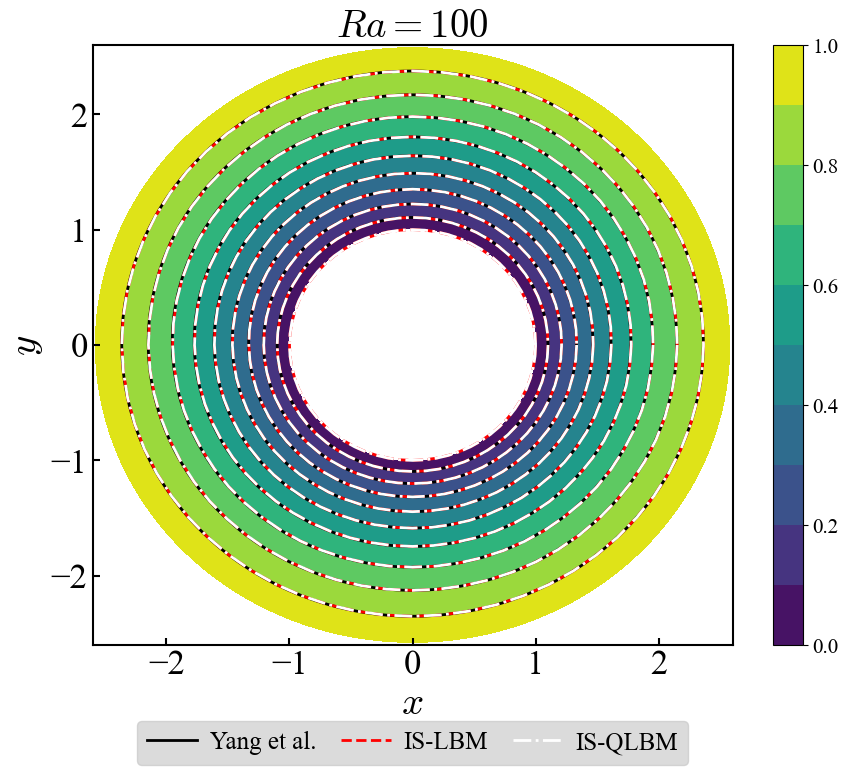

In [49]:
import matplotlib.lines as mlines
X_center = 0.5 * (x_values[:-1, :-1] + x_values[1:, 1:])
Y_center = 0.5 * (y_values[:-1, :-1] + y_values[1:, 1:])

den_values1 = np.zeros((den_values.shape[1]+1,den_values.shape[0]))
den_values1[:-1,:] = den_values.T[:,:]
den_values1[-1,:] = den_values.T[0,:]
X_center1 = np.zeros((X_center.shape[1]+1,X_center.shape[0]))
X_center1[:-1,:] = X_center.T[:,:]
X_center1[-1,:]  = X_center.T[0,:]
Y_center1 = np.zeros((Y_center.shape[1]+1,Y_center.shape[0]))
Y_center1[:-1,:] = Y_center.T[:,:]
Y_center1[-1,:]  = Y_center.T[0,:]
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig = plt.figure(figsize=(10,10))
ax1 = plt.axes([0.056, 0.2, 0.8, 0.6])
ax01=plt.contourf(X_center1, Y_center1, den_values1, 11,cmap='viridis')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
plt.contour(X_center1, Y_center1, den_values1,11,colors='k',linestyles='-',linewidths = 2,zorder=10)
plt.contour(X00/(Lx/1.6),Y00/(Lx/1.6),T00,11,colors='r',linestyles='--',linewidths = 2,zorder=10)
plt.contour(X00/(Lx/1.6),Y00/(Lx/1.6),T00q,11,colors='w',linestyles='-.',linewidths = 2,zorder=10)
proxy_artists = [mlines.Line2D([0],[0], color='k',linestyle= '-',linewidth=2),
                 mlines.Line2D([0],[0], color='r',linestyle= '--',linewidth=2),
                 mlines.Line2D([0],[0], color='w',linestyle= '-.',linewidth=2)]
legend_labels = ['Yang et al.','IS-LBM','IS-QLBM']

plt.legend(proxy_artists,legend_labels,bbox_to_anchor = (0.07,-0.2),loc=3,ncol=7,borderaxespad = 0,labelspacing = 0.1,columnspacing = 1.0,handletextpad = 0.5,fontsize=18,facecolor='lightgray')

ax1.set_xlabel('$x$', size = 28,fontdict = font1)
ax1.set_ylabel('$y$', size = 28,fontdict = font1)    
ax1.set_title('$Ra = 100$', fontsize = 28,fontdict = font)
ax1.tick_params(labelsize=25,axis="both", which="major", direction="in", width=1.5, length=5)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)

#plt.savefig('Ra=100_T.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

In [50]:

points = np.column_stack((X_center.ravel(), Y_center.ravel())) 

Ux_ref = griddata(points, results['U'].ravel(), (X_cart/(Lx/1.6), Y_cart/(Lx/1.6)), method='cubic')
Uy_ref = griddata(points, results['V'].ravel(), (X_cart/(Lx/1.6), Y_cart/(Lx/1.6)), method='cubic')

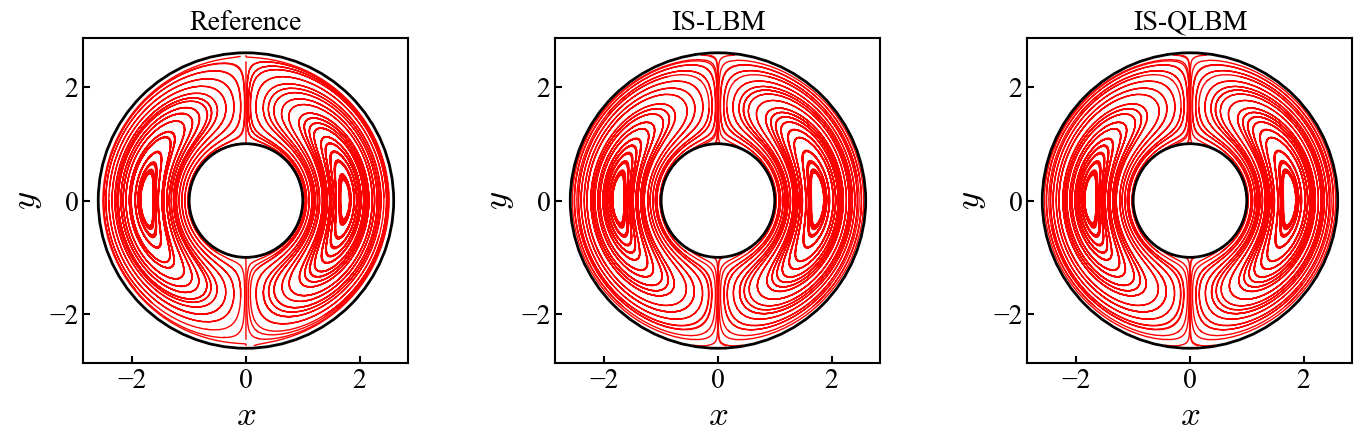

In [51]:
fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])

plt.streamplot(X_cart/(Lx/1.6), Y_cart/(Lx/1.6),Ux_ref,Uy_ref,density=1.3,arrowstyle='-',color='r', linewidth=1,broken_streamlines=False)

ax1.set_xlabel('$x$', size = 25,fontdict = font1)
ax1.set_ylabel('$y$', size = 25,fontdict = font1)    
ax1.set_title('Reference', fontsize = 20,fontdict = font)
ax1.set_xlim(x_min/(Lx/1.6), x_max/(Lx/1.6))
ax1.set_ylim(y_min/(Lx/1.6), y_max/(Lx/1.6))
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
circle = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='white', fill=True, linestyle='-', linewidth=0.1,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle)
circle1 = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle1)
circle2 = plt.Circle((0, 0), Lx/1.6*2.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle2)
plt.gca().set_aspect('equal')
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)




ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
plt.streamplot(X_cart/(Lx/1.6), Y_cart/(Lx/1.6), Ux_interp, Uy_interp, density=1.3,arrowstyle='-', color='red', linewidth=1,broken_streamlines=False)
ax2.set_xlabel('$x$', size = 25,fontdict = font1)
ax2.set_ylabel('$y$', size = 25,fontdict = font1)    
ax2.set_title('IS-LBM', fontsize = 20,fontdict = font)
ax2.set_xlim(x_min/(Lx/1.6), x_max/(Lx/1.6))
ax2.set_ylim(y_min/(Lx/1.6), y_max/(Lx/1.6))
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
circle = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='white', fill=True, linestyle='-', linewidth=0.1,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle)
circle1 = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle1)
circle2 = plt.Circle((0, 0), Lx/1.6*2.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle2)
plt.gca().set_aspect('equal')
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)


ax3 = plt.axes([0.528, 0.2, 0.18, 0.65])
plt.streamplot(X_cart/(Lx/1.6), Y_cart/(Lx/1.6), Ux_interp_q, Uy_interp_q, density=1.3,arrowstyle='-', color='red', linewidth=1,broken_streamlines=False)
circle = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='white', fill=True, linestyle='-', linewidth=0.1,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle)
circle1 = plt.Circle((0, 0), Lx/1.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle1)
circle2 = plt.Circle((0, 0), Lx/1.6*2.6/(Lx/1.6), color='k', fill=False, linestyle='-', linewidth=2.0,alpha = 1.0,zorder = 5.0)
plt.gca().add_patch(circle2)
plt.gca().set_aspect('equal')
ax3.set_xlabel('$x$', size = 25,fontdict = font1)
ax3.set_ylabel('$y$', size = 25,fontdict = font1)    
ax3.set_title('IS-QLBM', fontsize = 20,fontdict = font)
ax3.set_xlim(x_min/(Lx/1.6), x_max/(Lx/1.6))
ax3.set_ylim(y_min/(Lx/1.6), y_max/(Lx/1.6))
ax3.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax3.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

#plt.savefig('ISLBM-Ra-100-streamline.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

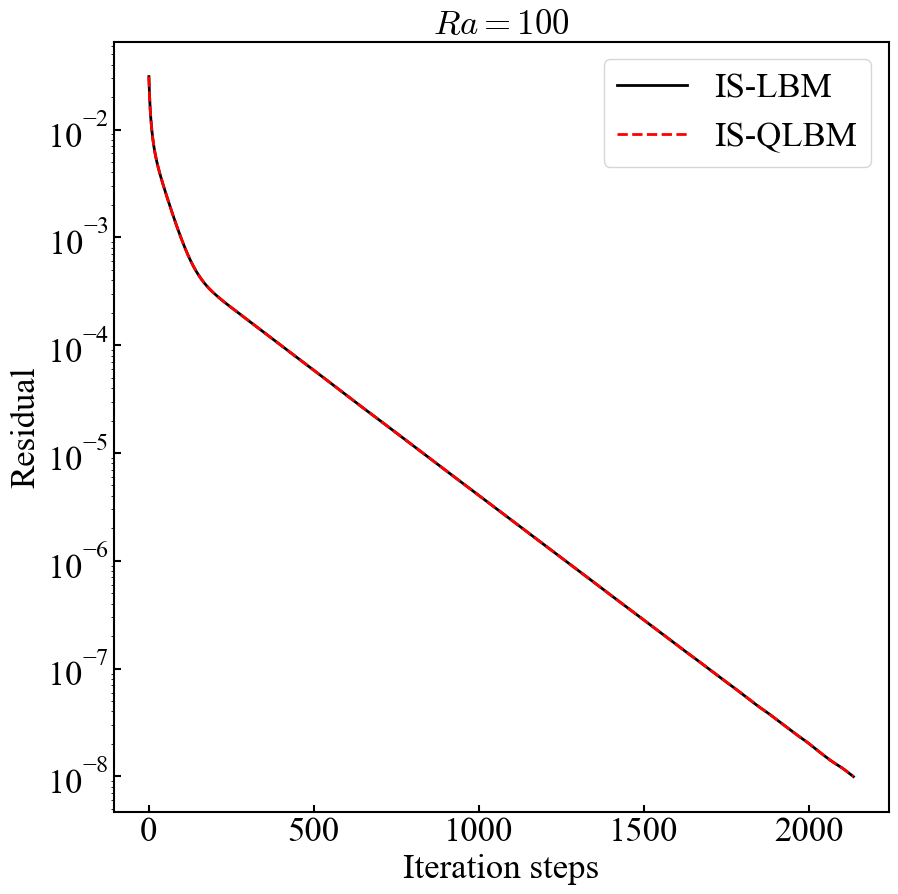

In [52]:
fig = plt.figure(figsize=(10, 10))

x_errorl = np.linspace(0,np.array(c_error).shape[0]-1,np.array(c_error).shape[0])
plt.plot(x_errorl[1:], c_error[1:], 'k-',linewidth = 2,label = 'IS-LBM')
plt.plot(x_errorl[1:], q_error[1:], 'r--',linewidth = 2,label = 'IS-QLBM')

plt.yscale('log')
plt.title('$Ra = 100$', size=25)
plt.xlabel('Iteration steps', size=25)
plt.ylabel('Residual', size=25)
plt.tick_params(labelsize=25,axis="both", which="major", direction="in", width=1.5, length=5)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)


plt.legend(loc=0,ncol=1,fontsize=25)
#plt.savefig('Ra=100_error.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

In [53]:
import math
T_theta_0 = -(3.0*T[:,0] - 4.0*T[:,1] + T[:,2])/(2.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#(-11.0*T[:,0] + 18.0*T[:,1] - 9.0*T[:,2] + 2.0*T[:,3])/(6.0)#
T_theta_1 = (3.0*T[:,-1] - 4.0*T[:,-2] + T[:,-3])/(2.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#-(-11.0*T[:,-1] + 18.0*T[:,-2] - 9.0*T[:,-3] + 2.0*T[:,-4])/(6.0)#
T_theta_0 = (-11.0*T[:,0] + 18.0*T[:,1] - 9.0*T[:,2] + 2.0*T[:,3])/(6.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#
T_theta_1 = -(-11.0*T[:,-1] + 18.0*T[:,-2] - 9.0*T[:,-3] + 2.0*T[:,-4])/(6.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#


k_0 = math.log(2.6)/(2.0*np.pi)*np.sum((T_theta_0)*np.max(Y0[2,:]-Y0[1,:]))
k_1 = 2.6*math.log(2.6)/(2.0*np.pi)*np.sum((T_theta_1)*np.max(Y0[2,:]-Y0[1,:]))
print(k_0,k_1)

0.9995679490465442 1.0009249689690543


In [55]:
import math
T_theta_0 = -(3.0*Psi_qlbm3[t+1,:,0] - 4.0*Psi_qlbm3[t+1,:,1] + Psi_qlbm3[t+1,:,2])/(2.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#(-11.0*T[:,0] + 18.0*T[:,1] - 9.0*T[:,2] + 2.0*T[:,3])/(6.0)#
T_theta_1 = (3.0*Psi_qlbm3[t+1,:,-1] - 4.0*Psi_qlbm3[t+1,:,-2] + Psi_qlbm3[t+1,:,-3])/(2.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#-(-11.0*T[:,-1] + 18.0*T[:,-2] - 9.0*T[:,-3] + 2.0*T[:,-4])/(6.0)#
T_theta_0 = (-11.0*Psi_qlbm3[t+1,:,0] + 18.0*Psi_qlbm3[t+1,:,1] - 9.0*Psi_qlbm3[t+1,:,2] + 2.0*Psi_qlbm3[t+1,:,3])/(6.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#
T_theta_1 = -(-11.0*Psi_qlbm3[t+1,:,-1] + 18.0*Psi_qlbm3[t+1,:,-2] - 9.0*Psi_qlbm3[t+1,:,-3] + 2.0*Psi_qlbm3[t+1,:,-4])/(6.0*(X0[:,1]-X0[:,0])/(Lx/1.6))#


k_0q = math.log(2.6)/(2.0*np.pi)*np.sum((T_theta_0)*np.max(Y0[2,:]-Y0[1,:]))
k_1q = 2.6*math.log(2.6)/(2.0*np.pi)*np.sum((T_theta_1)*np.max(Y0[2,:]-Y0[1,:]))
print(k_0q,k_1q)

0.9995679489889121 1.0009249688885082
